In [144]:
#Import essential libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

In [243]:
#read file

df = pd.read_csv('/Users/mac/Downloads/Data Analyst Assessment Dataset/Assessment Dataset -.csv')
df.head()

(df['Status'] == 'Successful').sum()

#noticed an error with electricity
df['product'] = df['product'].str.capitalize()

In [84]:
# null check

df.isna().sum()

#the output here shows Updated Time and Vendiing channel column both have null values of 5195 and 3 respectively

Customer ID               0
Recipient                 0
Amount                    0
Tranx_Date                0
Tranx ID                  0
Updated Time           5195
Buying Price              0
Transaction Gateway       0
Seller Name               0
Vending Channel           3
Account Type              0
Location                  0
product                   0
Status                    0
dtype: int64

In [85]:
#check for dupes in Txn_id column just because having duplicatted Txn_id poses a problem.

df[df.duplicated(subset=['Tranx ID'], keep=False)]
# The output shows we are cleared off dupes with respect to Txn_id. This is good.

,Customer ID,Recipient,Amount,Tranx_Date,Tranx ID,Updated Time,Buying Price,Transaction Gateway,Seller Name,Vending Channel,Account Type,Location,product,Status


In [145]:
# modal imputationton to fill up nulls on Updated Time and Vending Channel Columns

for col in df.columns:
    if df[col].isna().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

df.isna().sum()

Customer ID            0
Recipient              0
Amount                 0
Tranx_Date             0
Tranx ID               0
Updated Time           0
Buying Price           0
Transaction Gateway    0
Seller Name            0
Vending Channel        0
Account Type           0
Location               0
product                0
Status                 0
is_success             0
response_time          0
dtype: int64

In [272]:
# Standardize Status column

df['Status'] = df['Status'].str.upper().str.strip()

In [273]:
# OneHot Encoding status column; just lke case when in sql
df['is_success'] = np.where(df['Status'] == 'SUCCESSFUL', 1, 0)
df['is_success'].sum()

np.int64(643456)

# 1. In your view identify KPI's to track with reasons backed up with report/Analysis

In [274]:
#overview
transaction_summary = df['Status'].value_counts()
transaction_summary

Status
SUCCESSFUL                           643456
OTHER ERRORS                           2416
TOO MUCH REQUESTS/SYSTEM TOO BUSY      1033
VALIDATION ERROR                        736
WRONG PRODUCT                           605
Name: count, dtype: int64

## A. TRANSACTION SUCCESS RATE:

Since the dataset contains Produuct Transaction Details; Customer ID, Amount, Buying Price, Product, Status, Tranx_Date, Updated Time, Transaction Gateway, Vending Channel and Location, it is therefore tantamount that the KPI's based on surface perception should include measures that speak to both Business and product performance as well as customers interaction.
Hence, Measures that speak to Revenue, Reliability, Performance, Profitability and Customer behavior would readily come to mind.

Transaction Success Rate basically measures System reliability and customer performance

it is basically expressed as; TSR = Successful Transactions / Total Transactions

This is key in Detecting failing integrations, Identifying unstable customers, Platform performance measurement


In [227]:
# Calculate Transaction Success Rate by Location and Product

success_rate = (
    df.groupby(['Location', 'product']).agg(
        total_transactions=('is_success', 'count'),
        successful_transactions=('is_success', 'sum')
    ).reset_index()
)
success_rate['success_rate'] = ((success_rate['successful_transactions'] / success_rate['total_transactions'])* 100).round(2)

# average success rate by location
location_avg = success_rate.groupby('Location')['success_rate'].mean().round(2).reset_index()
location_avg.rename(columns={'success_rate': 'avg_location_success_rate'}, inplace=True)

# append the average 
success_rate = success_rate.merge(location_avg, on='Location', how='left')

# Sort values by Location first, then by success_rate in descending order
success_rate = success_rate.sort_values(['Location', 'success_rate'], ascending=[True, False])

# Display the DataFrame without the default index
success_rate.reset_index(drop=True, inplace=True)
success_rate

,Location,product,total_transactions,successful_transactions,success_rate,avg_location_success_rate
0,Canada,airtime,10514,10182,96.84,78.63
1,Canada,data,1979,1888,95.40,78.63
2,Canada,pin,300,236,78.67,78.63
3,Canada,cabletv,3,2,66.67,78.63
4,Canada,Electricity,18,10,55.56,78.63
5,Nigeria,electricity,22,22,100.00,98.05
6,Nigeria,startimes,28,28,100.00,98.05
7,Nigeria,airtime,405656,404249,99.65,98.05
8,Nigeria,data,99723,98104,98.38,98.05
9,Nigeria,pin,938,904,96.38,98.05


In [110]:
# Pivot for plot

pivot_df = success_rate.pivot(
    index='Location',
    columns='product',
    values='success_rate'
)
pivot_df

product,Airtime,Cabletv,Data,Electricity,Pin,Startimes
Location,,,,,,
Canada,96.84,66.67,95.40,55.56,78.67,NaN
Nigeria,99.65,93.88,98.38,100.00,96.38,100.0
UK,99.67,98.24,97.19,83.75,100.00,NaN


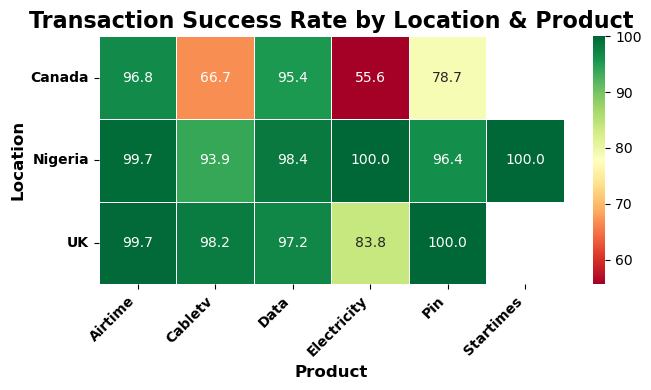

In [283]:
# Heatmap Plot:

plt.figure(figsize=(7, 4))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor='white'
)
plt.title("Transaction Success Rate by Location & Product", fontsize=16, fontweight='bold')
plt.ylabel("Location", fontsize=12, fontweight='bold')
plt.xlabel("Product", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(rotation=0, fontweight='bold')
plt.tight_layout()
plt.show()


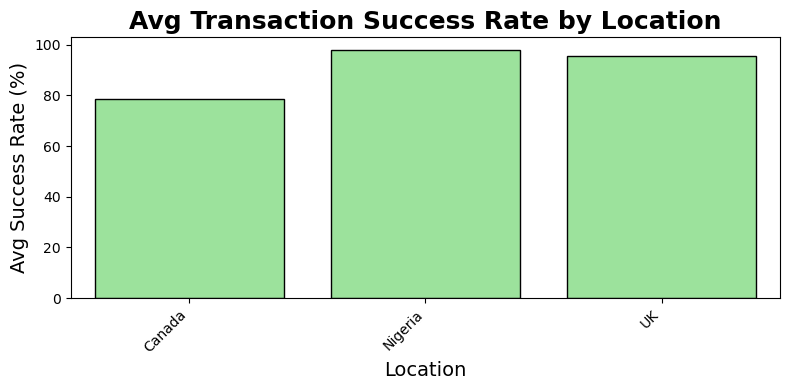

In [282]:
# Alternative: Barplot

plt.figure(figsize=(8, 4))
sns.barplot(
    data=success_rate,
    x='Location',
    y='avg_location_success_rate',
    color='#90EE90',
    edgecolor='black'
)
plt.title("Avg Transaction Success Rate by Location", fontsize=18, fontweight='bold')
plt.xlabel('Location', fontsize=14)
plt.ylabel('Avg Success Rate (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We see the TSR rate measured here:
Nigeria has → 98% success
UK has  = 96% success
Canada has = 79% success

## B. FAILURE RATE:

In [ ]:
Failure Rate (can also replicate the same as above for Failure Rate)
This is vital because it measures Transaction reliability risk
expressed as : Failure Rate = Failed / Total

It is as analysed in question 5

## C. ESTIMATED GROSS PROFIT

This measures business profitability and is basically expressed as Gross Profit = Amount − Buying Price
Why it matters

It can also be used to segment customers based on Profit generation
Some customers:


In [284]:
df['Gross Profit'] = df['Amount'] - df['Buying Price']
total_gross_profit = df['Gross Profit'].sum()
print(f"Total Gross Profit: {total_gross_profit:.2f}")

Total Gross Profit: 14250030.70


## D. AVERAGE RESPONSE TIME (Performance KPI)

This basically measures system laxity, expressed as Response Time = Updated Time − Tranx_Date

Slow response might lead to: duplicate transactions, increased timeouts and number of retries, customer complaints etc

for. instance, if Product Avg Response is
Airtime: 1 sec
Data: 5 sec
it can be concluded that Data product has latency issue.

In [286]:
success_value = df[df['Status']=="SUCCESSFUL"].groupby('Customer ID')
success_value.head()

,Customer ID,Recipient,Amount,Tranx_Date,Tranx ID,Updated Time,Buying Price,Transaction Gateway,Seller Name,Vending Channel,Account Type,Location,product,Status,is_success,Gross Profit
0,8304555449023,0807643XXXX,1650.00,2024-11-24,7222324112408349006592,2024-11-24 08:34:03,1615.00,GTW-3,CS1,Direct,postpaid,UK,Data,SUCCESSFUL,1,35.00
1,8304555449023,0808341XXXX,1150.00,2024-11-24,7232124112413371719392,2024-11-24 13:37:56,1132.50,GTW-3,CS1,Direct,postpaid,UK,Airtime,SUCCESSFUL,1,17.50
2,8304555449023,0703388XXXX,850.00,2024-11-24,7232424112409020587992,2024-11-24 09:02:45,843.00,GTW-2,CS2,Direct,postpaid,UK,Airtime,SUCCESSFUL,1,7.00
3,8304555449023,0806770XXXX,750.00,2024-11-24,7222424112420356982192,2024-11-24 20:35:44,746.50,GTW-2,CS2,Direct,postpaid,UK,Airtime,SUCCESSFUL,1,3.50
4,8304555449023,0802066XXXX,850.00,2024-11-24,7222124112408315785092,2024-11-24 08:31:22,843.00,GTW-3,CS1,Direct,postpaid,UK,Airtime,SUCCESSFUL,1,7.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
648241,373351941589,0912663XXXX,10650.00,2024-11-29,702124112910289393692,2024-11-29 10:28:33,10400.00,GTW-3,CS1,Third Party,prepaid,Canada,Airtime,SUCCESSFUL,1,250.00
648242,373351941589,0807113XXXX,10650.00,2024-11-29,702324112910287053792,2024-11-29 10:28:35,10250.00,GTW-3,CS1,Third Party,prepaid,Canada,Airtime,SUCCESSFUL,1,400.00
648243,373351941589,0913290XXXX,15650.00,2024-11-29,702424112910286027592,2024-11-29 10:28:37,15275.00,GTW-8,CS7,Third Party,prepaid,Canada,Airtime,SUCCESSFUL,1,375.00
648244,3733625420153,0702547XXXX,1650.00,2024-11-29,702424112913164073892,2024-11-29 13:16:03,1630.00,GTW-8,CS7,Direct,prepaid,Canada,Airtime,SUCCESSFUL,1,20.00


## 2. Average Response Time per Product

In [130]:
df['response_time'] = pd.to_datetime(df['Tranx_Date']) - pd.to_datetime(df['Updated Time'])

avg_response = df.groupby('product')['response_time'].mean()

avg_response

product
Airtime       0 days 00:26:33.993516522
Cabletv       3 days 08:59:45.690045248
Data          0 days 01:11:44.863843546
Electricity   2 days 22:39:54.637400228
Pin           0 days 00:24:41.803066989
Startimes     3 days 08:45:36.071428571
Name: response_time, dtype: timedelta64[ns]

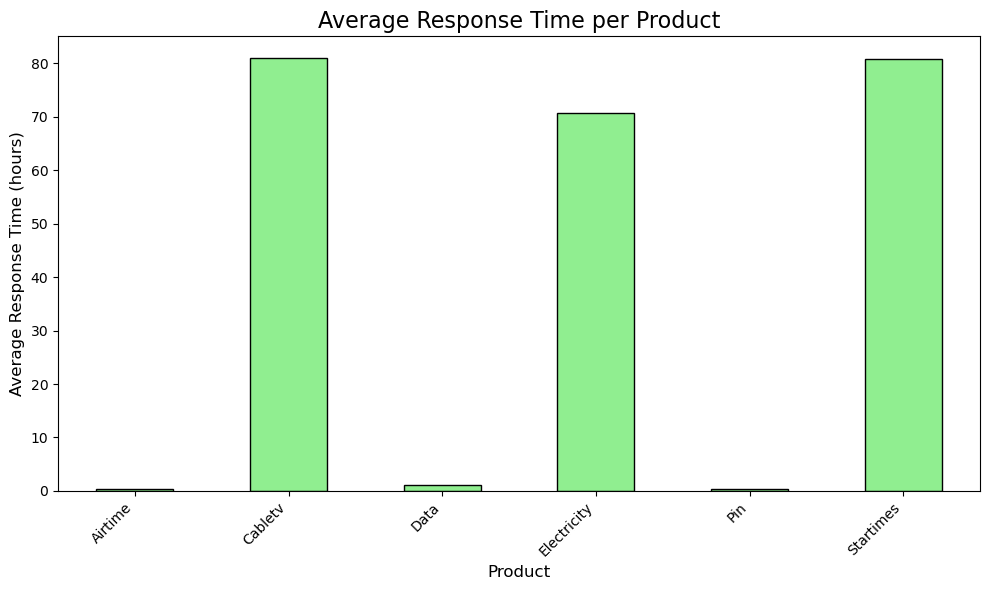

In [133]:
# Visual for Average Response Time per Product

avg_response_hours = avg_response.dt.total_seconds() / 3600
plt.figure(figsize=(10, 6))
avg_response_hours.plot(kind='bar', color='#90EE90', edgecolor='black')
plt.title('Average Response Time per Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Average Response Time (hours)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# The lower the better

## 3. Daily Trend Chart for Top 5 Customers

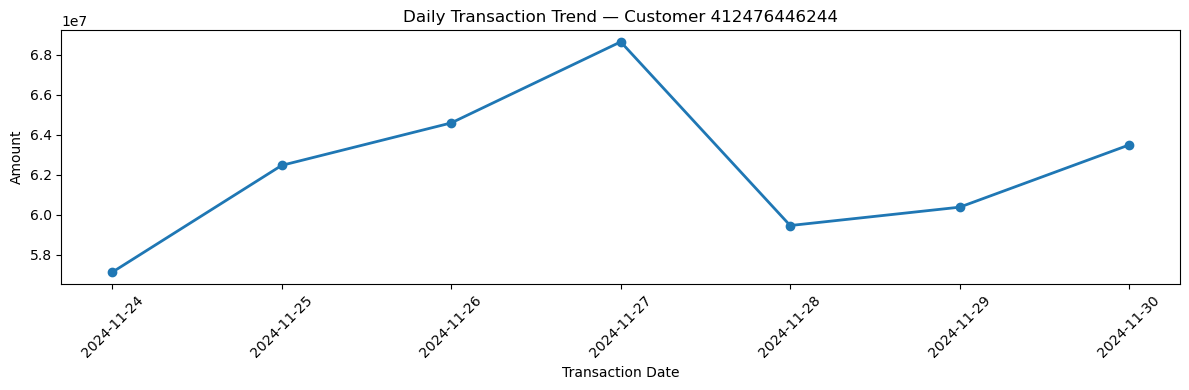

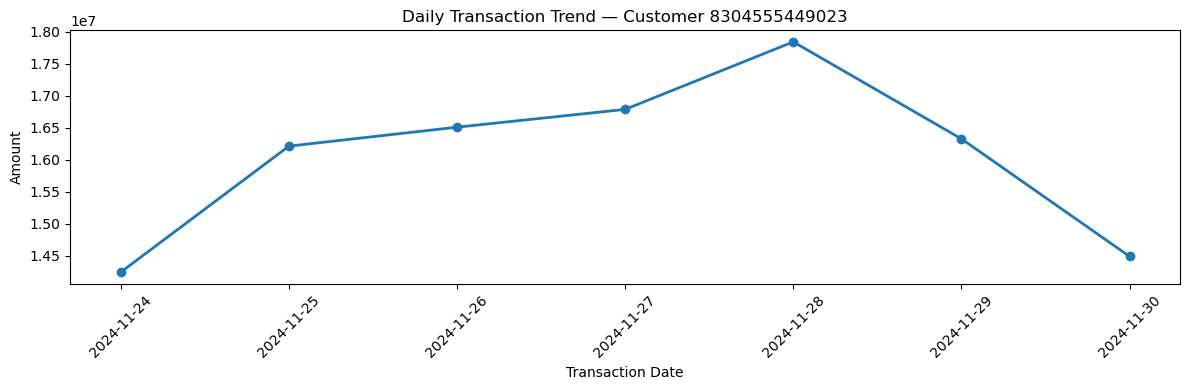

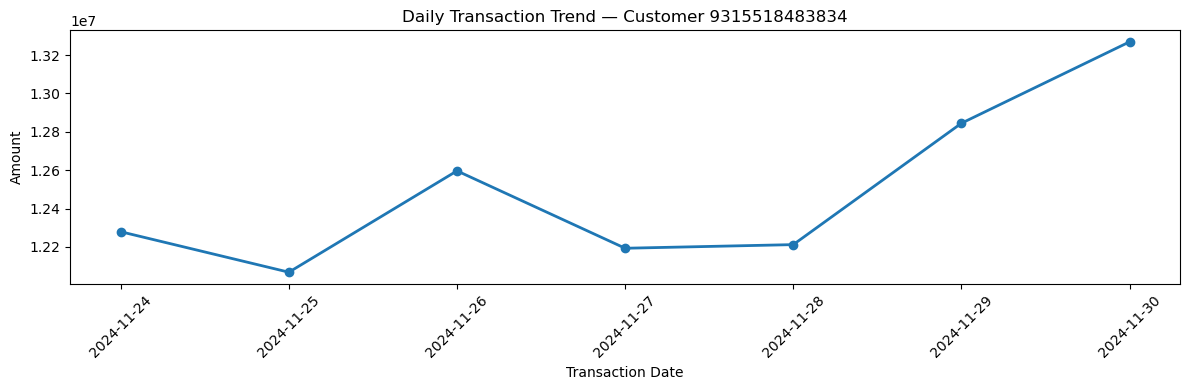

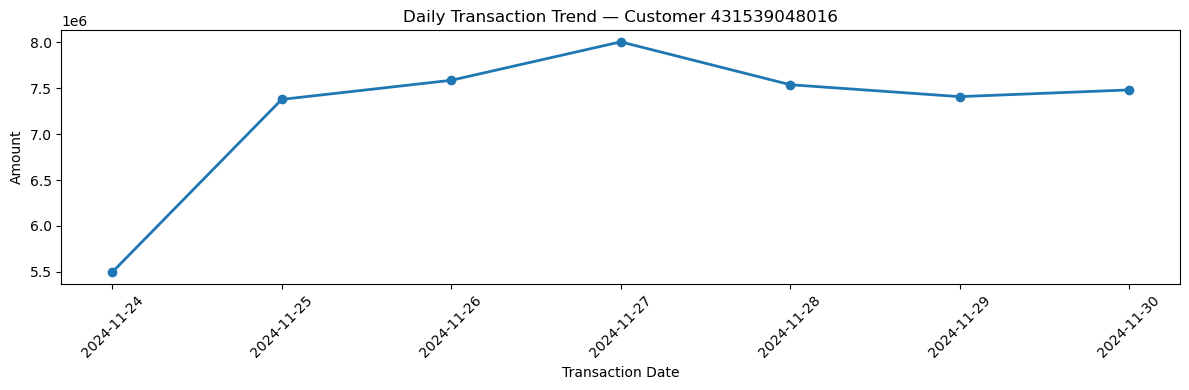

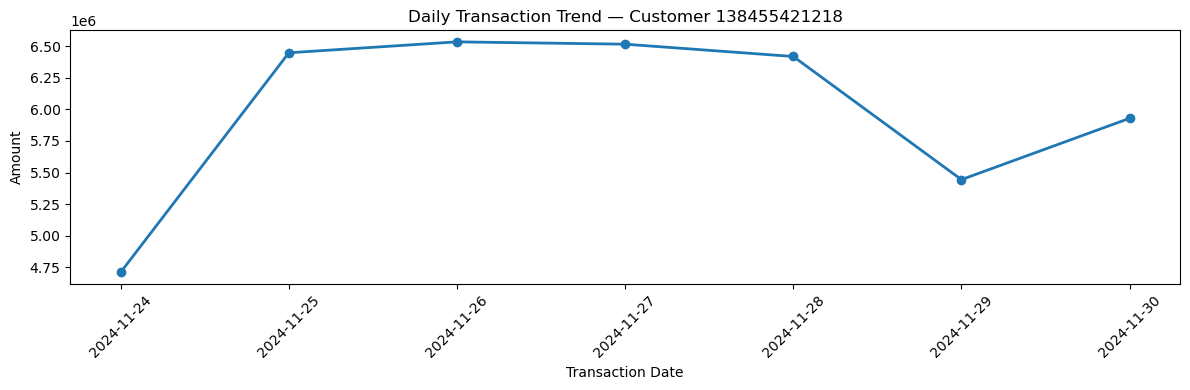

In [263]:
# ensure datetime
df['Tranx_Date'] = pd.to_datetime(df['Tranx_Date']).dt.date

# filter top5
trend = df[df['Customer ID'].isin(top5)]

# loop and plot each customer
for cust in top5:
    
    cust_df = (
        trend[trend['Customer ID'] == cust]
        .groupby('Tranx_Date')['Amount']
        .sum()
        .sort_index()
    )

    plt.figure(figsize=(12,4))
    
    plt.plot(
        cust_df.index,
        cust_df.values,
        marker='o',
        linewidth=2
    )
    
    plt.title(f"Daily Transaction Trend — Customer {cust}")
    plt.xlabel("Transaction Date")
    plt.ylabel("Amount")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## merged line chart

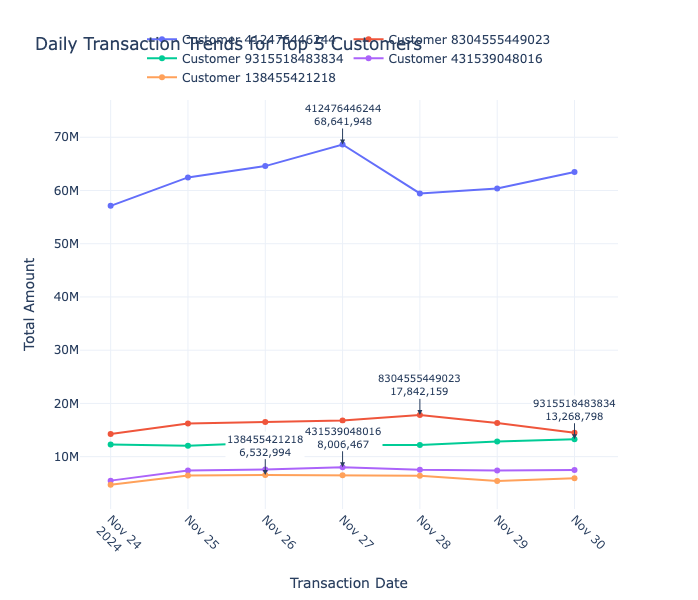

In [267]:
fig = go.Figure()

# Add a trace for each customer
for cust in top5:
    cust_data = daily_amounts[daily_amounts['Customer ID'] == cust]

    fig.add_trace(go.Scatter(
        x=cust_data['Tranx_Date'],
        y=cust_data['Amount'],
        mode='lines+markers',
        name=f'Customer {cust}',
        showlegend=True,          # ensure one legend entry only
        marker=dict(size=6),
        line=dict(width=2),
        hovertemplate='<b>Date</b>: %{x}<br><b>Amount</b>: %{y:,.2f}<extra></extra>'
    ))

    # add ONLY one max annotation per customer
    if not cust_data.empty:
        max_point = cust_data.loc[cust_data['Amount'].idxmax()]

        fig.add_annotation(
            x=max_point['Tranx_Date'],
            y=max_point['Amount'],
            text=f"{cust}<br>{max_point['Amount']:,.0f}",
            showarrow=True,
            arrowhead=2,
            ax=0,
            ay=-30,
            font=dict(size=10),
            bgcolor="white"
        )

# Layout
fig.update_layout(
    title='Daily Transaction Trends for Top 5 Customers',
    xaxis_title='Transaction Date',
    yaxis_title='Total Amount',
    template='plotly_white',
    hovermode='x unified',   # cleaner hover
    height=600,
    width=1000,

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    xaxis=dict(
        tickangle=45
    )
)

fig.show()

## 4. Top 10 Least Performing Customers per Product


In [275]:
# Sort by highest failure rate

least = (
df.groupby(['product','Customer ID'])['Status']
.apply(lambda x:(x!="SUCCESSFUL").sum()/len(x))
.reset_index(name='failure_rate')
.sort_values(['product','failure_rate'], ascending=[True,False])
.groupby('product')
.head(10)
)
least

# # Failure Rate per Row
# summary['Failure Rate'] = summary['Failed_Count'] / summary['Total_Count']
# summary['Failure Rate']

,product,Customer ID,failure_rate
20,Airtime,3315408484157,1.00
31,Airtime,8156589470954,1.00
23,Airtime,4315456478990,0.85
24,Airtime,4373359549892,0.14
33,Airtime,8373358948958,0.05
22,Airtime,3733677491279,0.05
28,Airtime,6315476430868,0.04
40,Airtime,83733676454855,0.03
25,Airtime,5365347429637,0.03
30,Airtime,7733525453138,0.02


# 5. From the Data, Kindly generate a summary table using the header below

### Note: Kindly share your python/R file used for the analysis. Also include notes in your code

### Customer ID,Successful Facevalue,Failed FaceValue,Estimated Gross Profit,% Value Contribution, Successful Count, Failure Rate, Airtime Failure Rate, Data Failure Rate, CableTV Failure Rate, Electricty Failure Rate

In [156]:
df2 = pd.read_csv('/Users/mac/Downloads/Data Analyst Assessment Dataset/Assessment Dataset -.csv')

# just to see all unique status and product for possible data cleaning
df2['Status'].unique()
df2['product'].unique()

# some cleasing as done previously
#df2['product'] = df2['product'].str.capitalize()
#df2['Status'] = df2['Status'].str.upper().str.strip()
#df2['product'] = df['product'].str.upper().str.strip()

array(['Data', 'Airtime', 'Cabletv', 'Electricity', 'Pin', 'Startimes'],
      dtype=object)

In [181]:
#Categorize into sucess and failed (Basically adds two columns: Success an Failed just like how OneHotEncoding works)

df2['success'] = np.where(df2['Status'] == 'SUCCESSFUL', 1, 0)
df2['failed']  = np.where(df2['Status'] == 'SUCCESSFUL', 0, 1)

In [182]:
# check
df2['success'].sum()
df2['failed'].sum()

np.int64(643456)

In [183]:
# check
df2['Status'].value_counts()

Status
SUCCESSFUL                           643456
OTHER ERRORS                           2416
TOO MUCH REQUESTS/SYSTEM TOO BUSY      1033
VALIDATION ERROR                        736
WRONG PRODUCT                           605
Name: count, dtype: int64

In [184]:
# add Profit column
df2['profit'] = df2['Amount'] - df2['Buying Price']


In [280]:
# just to ensure pandas display numbers without scientific format
pd.set_option('display.float_format', '{:.2f}'.format) 

# Column Aggregation
summary = df2.groupby('Customer ID').agg(
    Successful_Facevalue=('Amount', lambda x: x[df2.loc[x.index, 'Status'] == 'SUCCESSFUL'].sum()),
    Failed_FaceValue=('Amount', lambda x: x[df2.loc[x.index, 'Status'] != 'SUCCESSFUL'].sum()),
    Estimated_Gross_Profit=('profit', lambda x: x[df2.loc[x.index, 'Status'] == 'SUCCESSFUL'].sum()),
    Successful_Count=('success', 'sum'), 
    Failed_Count=('failed', 'sum'), 
    Total_Count=('Tranx ID', 'count')
).reset_index()

summary.head()

,Customer ID,Successful_Facevalue,Failed_FaceValue,Estimated_Gross_Profit,Successful_Count,Failed_Count,Total_Count
0,16414468728,9750.00,0.00,162.50,5,0,5
1,138455421218,41097961.00,898585.00,811985.00,27354,515,27869
2,151172469278,12450.00,0.00,262.50,3,0,3
3,312645843913,11224559.00,293150.00,213710.34,5695,68,5763
4,315382484218,38295158.00,567280.00,658504.91,33634,229,33863


In [279]:
# Failure Rate per Row
summary['Failure Rate'] = summary['Failed_Count'] / summary['Total_Count']
summary['Failure Rate'].head()

0   0.00
1   0.02
2   0.00
3   0.01
4   0.01
Name: Failure Rate, dtype: float64

In [240]:
# Overall Failure Rate
failure_rate_avg = (summary['Failed_Count'].sum() / summary['Total_Count'].sum())
print(f"Overall Failure Rate: {failure_rate_avg:.2%} (Which is quite fair")


Overall Failure Rate: 0.74%


In [198]:
# % Value Contribution
total_success_value = summary['Successful_Facevalue'].sum()

summary['% Value Contribution'] = (
    summary['Successful_Facevalue'] / total_success_value
) * 100
total_success_value

np.float64(816454696.14)

In [277]:
# Product Failure Rates
product_fail = (
    df2.groupby(['Customer ID','product'])['failed']
    .mean()
    .unstack()
)
product_fail.head()

product,Airtime,Cabletv,Data,Electricity,Pin,Startimes
Customer ID,,,,,,
16414468728,0.00,NaN,0.00,NaN,NaN,NaN
138455421218,0.01,NaN,0.06,0.17,NaN,NaN
151172469278,0.00,NaN,0.00,NaN,NaN,NaN
312645843913,0.00,0.09,0.04,0.05,NaN,NaN
315382484218,0.00,NaN,0.05,NaN,NaN,NaN


In [209]:
# Rename columns
product_fail = product_fail.rename(columns={
    'AIRTIME':'Airtime Failure Rate',
    'DATA':'Data Failure Rate',
    'CABLETV':'CableTV Failure Rate',
    'ELECTRICITY':'Electricty Failure Rate'
})


In [210]:
# Merge Tables
final_table = summary.merge(
    product_fail,
    on='Customer ID',
    how='left'
)


In [211]:
# Drop columns we dont need any more
final_table = final_table.drop(
    columns=['Failed_Count','Total_Count']
)

In [278]:
# Spool Output
print("\nCustomer Performance Summary Table\n")
print(final_table.head(5))



Customer Performance Summary Table

    Customer ID  Successful_Facevalue  Failed_FaceValue  \
0   16414468728               9750.00              0.00   
1  138455421218           41097961.00         898585.00   
2  151172469278              12450.00              0.00   
3  312645843913           11224559.00         293150.00   
4  315382484218           38295158.00         567280.00   

   Estimated_Gross_Profit  Successful_Count  % Value Contribution  Airtime  \
0                  162.50                 5                  0.00     0.00   
1               811985.00             27354                  5.03     0.01   
2                  262.50                 3                  0.00     0.00   
3               213710.34              5695                  1.37     0.00   
4               658504.91             33634                  4.69     0.00   

   Cabletv  Data  Electricity  Pin  Startimes  
0      NaN  0.00          NaN  NaN        NaN  
1      NaN  0.06         0.17  NaN        N

In [213]:
# Export to CSV

final_table.to_csv("Customer_Summary_Table.csv", index=False)

print("\nOutput saved as: Customer_Summary_Table.csv")


Output saved as: Customer_Summary_Table.csv
